In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['HF_HOME'] = "/mmfs1/home/alexeyy/storage/.cache/huggingface"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data.serialize import SerializerSettings
from models.utils import grid_iter
from models.llmtime import get_llmtime_predictions_data
from data.small_context import get_datasets
from models.validation_likelihood_tuning import get_autotuned_predictions_data

%load_ext autoreload
%autoreload 2

def plot_preds(train, test, pred_dict, model_name, show_samples=False):
    pred = pred_dict['median']
    pred = pd.Series(pred, index=test.index)
    plt.figure(figsize=(8, 6), dpi=100)
    plt.plot(train)
    plt.plot(test, label='Truth', color='black')
    plt.plot(pred, label=model_name, color='purple')
    # shade 90% confidence interval
    samples = pred_dict['samples']
    lower = np.quantile(samples, 0.05, axis=0)
    upper = np.quantile(samples, 0.95, axis=0)
    plt.fill_between(pred.index, lower, upper, alpha=0.3, color='purple')
    if show_samples:
        samples = pred_dict['samples']
        # convert df to numpy array
        samples = samples.values if isinstance(samples, pd.DataFrame) else samples
        for i in range(min(10, samples.shape[0])):
            plt.plot(pred.index, samples[i], color='purple', alpha=0.3, linewidth=1)
    plt.legend(loc='upper left')
    if 'NLL/D' in pred_dict:
        nll = pred_dict['NLL/D']
        if nll is not None:
            plt.text(0.03, 0.85, f'NLL/D: {nll:.2f}', transform=plt.gca().transAxes, bbox=dict(facecolor='white', alpha=0.5))
    plt.show()

## Define models ##

In [2]:
llama_hypers = dict(
    temp=1.0,
    alpha=0.99,
    beta=0.3,
    basic=False,
    settings=SerializerSettings(base=10, prec=3, time_sep=',', bit_sep='', plus_sign='', minus_sign='-', signed=True), 
)

model_hypers = {
    'llama-7b': {'model': 'llama-7b', **llama_hypers},
}

model_predict_fns = {
    'llama-7b': get_llmtime_predictions_data,
}

model_names = list(model_predict_fns.keys())

## Running LLMTime and Visualizing Results ##

In [3]:
datasets = get_datasets()
ds_name = 'AirPassengersDataset'

data = datasets[ds_name]
train, test = data # or change to your own data


Sampling with best hyper... defaultdict(<class 'dict'>, {'model': 'llama-7b', 'temp': 1.0, 'alpha': 0.99, 'beta': 0.3, 'basic': False, 'settings': SerializerSettings(base=10, prec=3, signed=True, fixed_length=False, max_val=10000000.0, time_sep=',', bit_sep='', plus_sign='', minus_sign='-', half_bin_correction=True, decimal_point='', missing_str=' Nan'), 'dataset_name': 'AirPassengersDataset'}) 
 with NLL inf


  0%|          | 0/1 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 1/1 [02:46<00:00, 166.67s/it]


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


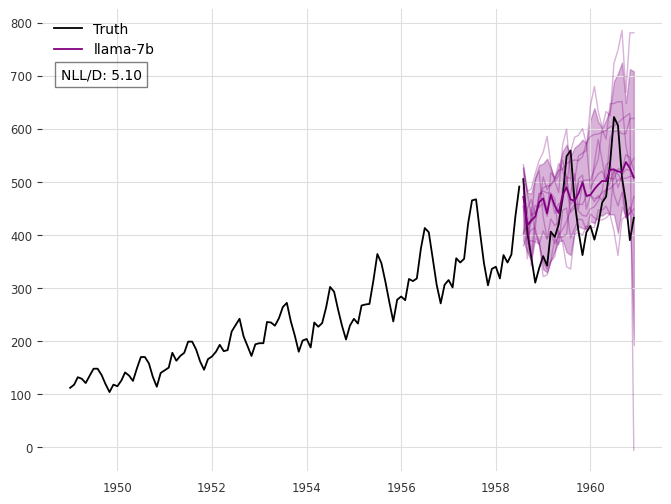

In [ ]:

out = {}
for model in model_names: # GPT-4 takes a about a minute to run
    model_hypers[model].update({'dataset_name': ds_name}) # for promptcast
    hypers = list(grid_iter(model_hypers[model]))
    num_samples = 10
    pred_dict = get_autotuned_predictions_data(train, test, hypers, num_samples, model_predict_fns[model], verbose=False, parallel=False)
    out[model] = pred_dict
    plot_preds(train, test, pred_dict, model, show_samples=True)


In [ ]:

print(pred_dict.keys())
print(type(pred_dict['median']))
print(pred_dict['median'].shape)
print(type(pred_dict['samples']))
print(pred_dict['samples'].shape)



dict_keys(['samples', 'median', 'info', 'completions_list', 'input_strs', 'NLL/D', 'best_hyper'])
<class 'pandas.core.series.Series'>
(29,)
<class 'pandas.core.frame.DataFrame'>
(10, 29)


In [11]:

list(model_predict_fns.keys())[0]


'llama-7b'